In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
import json
import pandas as pd
import os
import numpy as np
import string
import csv
from datetime import datetime

In [ ]:
# --------------------------------------------------------
# Install required packages
# --------------------------------------------------------
!pip install sentence-transformers faiss-cpu rank-bm25 transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 78.0 MB/s eta 0:00:00


In [ ]:
# --------------------------------------------------------
# ML Imports
# --------------------------------------------------------
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss
import pickle
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

In [ ]:
input_file = '/content/drive/MyDrive/HealthCareMagic-100k-en.jsonl'
output_dir = '/content/drive/MyDrive/healthcare_rag_chunks'

# Create output folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# --------------------------------------------------------
# Load Conversations from JSONL
# --------------------------------------------------------
def load_conversations(file_path, limit=5000):
    """Read conversations from JSONL file"""
    conversations = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            if idx >= limit:
                break

            data = json.loads(line.strip())

            if isinstance(data, str):
                conversations.append(data)
            elif isinstance(data, dict):
                for field in ['text', 'conversation', 'content']:
                    if field in data:
                        conversations.append(data[field])
                        break

            if (idx + 1) % 1000 == 0:
                print(f"Loaded {idx + 1} conversations...")

    print(f"Total loaded: {len(conversations)}")
    return conversations
conversations = load_conversations(input_file, limit=5000)


Loaded 1000 conversations...
Loaded 2000 conversations...
Loaded 3000 conversations...
Loaded 4000 conversations...
Loaded 5000 conversations...
Total loaded: 5000


In [ ]:
# --------------------------------------------------------
# Chunk a Single Conversation
# --------------------------------------------------------
def chunk_conversation(text, conv_id):
    """Split one conversation into chunks (question + answer pairs)"""
    chunks = []

    parts = re.split(r'(?=<human>:)', text)

    for turn_idx, part in enumerate(parts):
        part = part.strip()
        if not part or '<human>:' not in part:
            continue

        question_match = re.search(r'<human>:\s*(.*?)(?=<bot>:|$)', part, re.DOTALL)
        if not question_match:
            continue

        question = question_match.group(1).strip()

        answer_match = re.search(r'<bot>:\s*(.*?)(?=<human>:|$)', part, re.DOTALL)
        answer = answer_match.group(1).strip() if answer_match else ""

        chunk = {
            'chunk_id': f"conv_{conv_id}_turn_{turn_idx}",
            'conversation_id': conv_id,
            'question': question,
            'answer': answer,
            'full_text': part.strip()
        }
        chunks.append(chunk)

    return chunks


In [ ]:
# --------------------------------------------------------
# Process All Conversations
# --------------------------------------------------------
all_chunks = []

print("Processing conversations...")
for idx, conv in enumerate(conversations):
    chunks = chunk_conversation(conv, conv_id=idx)
    all_chunks.extend(chunks)

    if (idx + 1) % 500 == 0:
        print(f"Processed {idx + 1} conversations → {len(all_chunks)} chunks")

print(f"\n✅ Total chunks created: {len(all_chunks)}")

Processing conversations...
Processed 500 conversations → 500 chunks
Processed 1000 conversations → 1000 chunks
Processed 1500 conversations → 1500 chunks
Processed 2000 conversations → 2000 chunks
Processed 2500 conversations → 2500 chunks
Processed 3000 conversations → 3000 chunks
Processed 3500 conversations → 3500 chunks
Processed 4000 conversations → 4000 chunks
Processed 4500 conversations → 4500 chunks
Processed 5000 conversations → 5000 chunks

✅ Total chunks created: 5000



### **Embedding**


In [ ]:
# --------------------------------------------------------
# Load Embedding Model
# --------------------------------------------------------
EMBEDDING_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'

print(f"\nLoading embedding model: {EMBEDDING_MODEL}")
embedding_model = SentenceTransformer(EMBEDDING_MODEL)
embedding_dim = embedding_model.get_sentence_embedding_dimension()
print(f"✅ Model loaded! Embedding dimension: {embedding_dim}")


Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded! Embedding dimension: 384


In [ ]:
# --------------------------------------------------------
# Prepare Texts for Embedding
# --------------------------------------------------------
def prepare_texts_for_embedding(chunks):
    """Prepare text from chunks for embedding"""
    texts = []
    for chunk in chunks:
        combined_text = f"Question: {chunk['question']}\nAnswer: {chunk['answer']}"
        texts.append(combined_text)
    return texts

texts_to_embed = prepare_texts_for_embedding(all_chunks)
print(f"\nPrepared {len(texts_to_embed)} texts for embedding")



Prepared 5000 texts for embedding


In [ ]:
# --------------------------------------------------------
# Generate Embeddings
# --------------------------------------------------------
print("\nGenerating embeddings...")
embeddings = embedding_model.encode(
    texts_to_embed,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"✅ Embeddings generated!")
print(f"Shape: {embeddings.shape}")
print(f"Memory size: {embeddings.nbytes / (1024**2):.2f} MB")


Generating embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

✅ Embeddings generated!
Shape: (5000, 384)
Memory size: 7.32 MB


In [ ]:
# --------------------------------------------------------
# Prepare BM25
# --------------------------------------------------------
def simple_tokenize(text):
    """Simple tokenization for BM25"""
    return text.lower().split()

tokenized_corpus = [simple_tokenize(text) for text in texts_to_embed]
print(f"Tokenized {len(tokenized_corpus)} documents")

bm25 = BM25Okapi(tokenized_corpus)
print("✅ BM25 index created")

bm25_path = os.path.join(output_dir, 'bm25_index.pkl')
with open(bm25_path, 'wb') as f:
    pickle.dump(bm25, f)
print(f"✅ BM25 index saved to: {bm25_path}")

Tokenized 5000 documents
✅ BM25 index created
✅ BM25 index saved to: /content/drive/MyDrive/healthcare_rag_chunks/bm25_index.pkl


In [ ]:
# --------------------------------------------------------
# Load Cross-Encoder Reranker
# --------------------------------------------------------
RERANKER_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
print(f"Loading reranker: {RERANKER_MODEL}")
reranker = CrossEncoder(RERANKER_MODEL)
print("✅ Reranker loaded")

Loading reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Reranker loaded


In [ ]:
# --------------------------------------------------------
# Load FLAN-T5
# --------------------------------------------------------
GENERATOR_MODEL = 'google/flan-t5-base'

print(f"Loading generator model: {GENERATOR_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(GENERATOR_MODEL)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(GENERATOR_MODEL)

device = "cuda" if torch.cuda.is_available() else "cpu"
generator_model = generator_model.to(device)
print(f"✅ Generator loaded on device: {device}")

Loading generator model: google/flan-t5-base


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Generator loaded on device: cpu


In [ ]:
# --------------------------------------------------------
# BM25 Keyword Search
# --------------------------------------------------------
def keyword_search(query, top_k=20):
    """Perform keyword search using BM25"""
    tokenized_query = simple_tokenize(query)
    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices):
        results.append({
            'chunk_idx': int(idx),
            'score': float(scores[idx]),
            'rank': rank + 1,
            'source': 'keyword'
        })

    return results

In [ ]:
# --------------------------------------------------------
# BM25 Only Search with Reranking
# --------------------------------------------------------
def bm25_only_search(query, top_k=10):
    """
    BM25 keyword search only → Cross-Encoder Reranking
    (No FAISS semantic search, No RRF fusion)
    """
    # Step 1: BM25 keyword search
    keyword_results = keyword_search(query, top_k=top_k * 3)

    # Step 2: Cross-Encoder Reranking
    rerank_pairs = []
    chunk_indices = []

    for result in keyword_results:
        idx = result['chunk_idx']
        chunk = all_chunks[idx]
        chunk_text = f"Question: {chunk['question']}\nAnswer: {chunk['answer']}"
        rerank_pairs.append([query, chunk_text])
        chunk_indices.append(idx)

    rerank_scores = reranker.predict(rerank_pairs)

    final_results = []
    for idx, rerank_score, bm25_result in zip(chunk_indices, rerank_scores, keyword_results):
        final_results.append({
            'chunk_idx': idx,
            'bm25_score': bm25_result['score'],
            'rerank_score': float(rerank_score),
            'chunk': all_chunks[idx]
        })

    final_results.sort(key=lambda x: x['rerank_score'], reverse=True)
    return final_results[:top_k]


In [ ]:
# --------------------------------------------------------
# Generate Answer
# --------------------------------------------------------
def generate_answer(query, context, max_length=1024):
    """Generate answer using FLAN-T5-base"""
    if "Doctor's Answer:" in context:
        doctor_answer = context.split("Doctor's Answer:")[-1].strip()
    elif "Doctor:" in context:
        doctor_answer = context.split("Doctor:")[-1].strip()
    elif "Doctor's Response:" in context:
        doctor_answer = context.split("Doctor's Response:")[-1].strip()
    else:
        doctor_answer = context

    doctor_answer = doctor_answer.split("Thank you for posting your query")[0].strip()

    if len(doctor_answer) < 50:
        doctor_answer = context

    prompt = f"""Based on this medical information, answer the patient's question.
    Medical Information:
{doctor_answer[:1000]}

Patient Question: {query[:300]}

Medical Answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = generator_model.generate(
            **inputs,
            max_length=max_length,
            min_length=50,
            num_beams=6,
            no_repeat_ngram_size=4,
            length_penalty=1.5,
            early_stopping=True,
            do_sample=False,
            repetition_penalty=1.3
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    answer_lower = answer.lower()
    query_start = query[:50].lower()

    is_bad_generation = (
        len(answer) < 30 or
        answer_lower.startswith(query_start) or
        answer.count(".") == 0
    )

    if is_bad_generation:
        return doctor_answer.strip()

    return answer.strip()


In [ ]:
# --------------------------------------------------------
# RAG Pipeline (BM25 Only)
# --------------------------------------------------------
def rag_pipeline_bm25_only(query, top_k=10):
    """RAG pipeline using BM25 only retrieval"""
    search_results = bm25_only_search(query, top_k=top_k)

    if not search_results:
        return {
            'query': query,
            'answer': "I couldn't find relevant information.",
            'context': None,
            'top_chunks': []
        }

    top_chunk = search_results[0]['chunk']
    full_context = f"Doctor's Answer: {top_chunk['answer']}"

    answer = generate_answer(query, full_context, max_length=1024)

    return {
        'query': query,
        'answer': answer,
        'context': full_context,
        'top_chunks': [
            {
                'chunk_id': r['chunk']['chunk_id'],
                'question': r['chunk']['question'][:200],
                'answer': r['chunk']['answer'][:200],
                'rerank_score': r['rerank_score']
            }
            for r in search_results[:5]
        ]
    }


In [ ]:
# --------------------------------------------------------
# Test with a Sample Query
# --------------------------------------------------------
test_query = "hi my nine year old son had a cough and flu symptons three months ago and the chesty sounding cough and green phlegm still remains."

print("\n" + "="*80)
result = rag_pipeline_bm25_only(test_query, top_k=10)

print(f"\n💡 GENERATED ANSWER:\n{result['answer']}")
print(f"\n📚 CONTEXT USED:\n{result['context'][:500]}...")
print(f"\n🔍 TOP RETRIEVED CHUNKS:")
for i, chunk in enumerate(result['top_chunks'][:3], 1):
    print(f"\n  {i}. Score: {chunk['rerank_score']:.4f}")
    print(f"     Q: {chunk['question'][:300]}...")
    print(f"     A: {chunk['answer'][:300]}...")



💡 GENERATED ANSWER:
My nine year old son had a cough and flu symptoms three months agoand the chesty sounding smell of it still remains. To treat that kindof allergy you can give him an over counter antihistamines once daily before going to bed

📚 CONTEXT USED:
Doctor's Answer: Hi, If the symptoms persist that long this suggests the presence of an allergic element. To treat that kind of allergy you can give him an over the counter antihistamines once daily before going to bed. A cough suppressant as dextromethorphan and an expectorant as Murine will help reduce the cough. Make sure he Chat Doctor.  If the green phlegm persists he might require an antibiotic. Hope I have answered your query. Let me know if I can assist you further....

🔍 TOP RETRIEVED CHUNKS:

  1. Score: 9.7764
     Q: hi my nine year old son had a cough and flu symptons three months ago and the chesty sounding cough and green phlegm still remains. it did seem to get better but never totally went and has now picked .

In [ ]:
# ========================================================
# TEST BM25-ONLY PIPELINE WITH 50 QUERIES & SAVE TO CSV
# ========================================================

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Load test data
print("Loading test conversations...")
test_conversations = load_conversations(input_file, limit=50)

# Extract questions and ground truths
test_queries = []
ground_truths = []
for conv_id, conversation in enumerate(test_conversations):
    chunks = chunk_conversation(conversation, conv_id)
    for chunk in chunks:
        if chunk['question']:
            test_queries.append(chunk['question'])
            ground_truths.append(chunk['answer'])

print(f"Extracted {len(test_queries)} questions")
print(f"Testing first 50...\n")

# Run evaluation
bm25_em_scores = []
bm25_f1_scores = []
bm25_results_detailed = []

for idx, (query, truth) in enumerate(zip(test_queries[:50], ground_truths[:50]), 1):
    print(f"\rEvaluating query {idx}/50...", end="", flush=True)

    result = rag_pipeline_bm25_only(query, top_k=10)
    prediction = result['answer']

    em = exact_match_score(prediction, truth)
    f1 = f1_score_tokens(prediction, truth)

    bm25_em_scores.append(em)
    bm25_f1_scores.append(f1)

    bm25_results_detailed.append({
        'query_number': idx,
        'question': query,
        'ground_truth': truth,
        'prediction': prediction,
        'context_used': result['context'][:2000] if result['context'] else "",
        'top_rerank_score': result['top_chunks'][0]['rerank_score'] if result['top_chunks'] else 0,
        'exact_match': em,
        'f1_score': round(f1, 4)
    })

# Print summary
print("\n\n" + "="*80)
print("📊 BM25 ONLY - EVALUATION RESULTS")
print("="*80)
print(f"\n  Exact Match:  {np.mean(bm25_em_scores)*100:.2f}%")
print(f"  Avg F1 Score: {np.mean(bm25_f1_scores)*100:.2f}%")
print(f"  Max F1 Score: {np.max(bm25_f1_scores)*100:.2f}%")
print(f"  Min F1 Score: {np.min(bm25_f1_scores)*100:.2f}%")

# Save to Google Drive
save_dir = '/content/drive/MyDrive/healthcare_rag_chunks'
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, f"bm25_only_50queries_results_{timestamp}.csv")
eval_df = pd.DataFrame(bm25_results_detailed)
eval_df.to_csv(csv_path, index=False)
print(f"\n✅ Results saved to Google Drive: {csv_path}")

Loading test conversations...
Total loaded: 50
Extracted 50 questions
Testing first 50...

Evaluating query 50/50...

📊 BM25 ONLY - EVALUATION RESULTS

  Exact Match:  14.00%
  Avg F1 Score: 32.24%
  Max F1 Score: 84.38%
  Min F1 Score: 6.67%

✅ Results saved to Google Drive: /content/drive/MyDrive/healthcare_rag_chunks/bm25_only_50queries_results_20260304_133104.csv


In [ ]:
# --------------------------------------------------------
# Define Evaluation Functions
# --------------------------------------------------------
def normalize_text(text):
    """Normalize text for fair comparison"""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())
    return text.strip()

def exact_match_score(prediction, ground_truth):
    """Returns 1 if normalized prediction == normalized ground truth, else 0"""
    return int(normalize_text(prediction) == normalize_text(ground_truth))

def f1_score_tokens(prediction, ground_truth):
    """Token-level F1 Score"""
    pred_tokens = normalize_text(prediction).split()
    truth_tokens = normalize_text(ground_truth).split()

    common = set(pred_tokens) & set(truth_tokens)

    if len(common) == 0:
        return 0.0

    precision = len(common) / len(pred_tokens) if pred_tokens else 0
    recall = len(common) / len(truth_tokens) if truth_tokens else 0

    if precision + recall == 0:
        return 0.0

    return 2 * (precision * recall) / (precision + recall)

In [ ]:
#--------------------------------------------------------
# Prepare Test Data
# --------------------------------------------------------
print("Loading test conversations...")
test_conversations = load_conversations(input_file, limit=50)

# Extract questions
test_queries = []
for conv_id, conversation in enumerate(test_conversations):
    chunks = chunk_conversation(conversation, conv_id)
    for chunk in chunks:
        if chunk['question']:
            test_queries.append(chunk['question'])

# Extract ground truth answers
ground_truths = []
for conv_id, conversation in enumerate(test_conversations[:50]):
    chunks = chunk_conversation(conversation, conv_id)
    for chunk in chunks:
        if chunk['question']:
            ground_truths.append(chunk['answer'])

print(f"Extracted {len(test_queries)} questions")
print(f"Ground truth answers: {len(ground_truths)}")


Loading test conversations...
Total loaded: 50
Extracted 50 questions
Ground truth answers: 50


In [ ]:
# --------------------------------------------------------
# CELL 22: Run BM25 Only Evaluation (EM + F1)
# --------------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("Running BM25-Only Evaluation on 50 test queries...\n")

bm25_em_scores = []
bm25_f1_scores = []
bm25_results_detailed = []

for idx, (query, truth) in enumerate(zip(test_queries[:50], ground_truths[:50]), 1):
    print(f"\rEvaluating query {idx}/50...", end="", flush=True)

    result = rag_pipeline_bm25_only(query, top_k=10)
    prediction = result['answer']

    em = exact_match_score(prediction, truth)
    f1 = f1_score_tokens(prediction, truth)

    bm25_em_scores.append(em)
    bm25_f1_scores.append(f1)

    bm25_results_detailed.append({
        'query_number': idx,
        'question': query[:200],
        'ground_truth': truth[:300],
        'prediction': prediction[:300],
        'exact_match': em,
        'f1_score': round(f1, 4)
    })


Running BM25-Only Evaluation on 50 test queries...

Evaluating query 50/50...

In [ ]:
# --------------------------------------------------------
# CELL 23: Print Evaluation Results
# --------------------------------------------------------
print("\n\n" + "="*80)
print("📊 BM25 ONLY - EVALUATION RESULTS")
print("="*80)

print(f"\n{'Metric':<30} {'Score':<15}")
print("-"*45)
print(f"{'Exact Match':<30} {np.mean(bm25_em_scores)*100:.2f}%")
print(f"{'F1 Score (Avg)':<30} {np.mean(bm25_f1_scores)*100:.2f}%")
print(f"{'F1 Score (Max)':<30} {np.max(bm25_f1_scores)*100:.2f}%")
print(f"{'F1 Score (Min)':<30} {np.min(bm25_f1_scores)*100:.2f}%")
print(f"\n{'Total Queries':<30} {len(bm25_em_scores)}")
print(f"{'Strict EM Matches':<30} {sum(bm25_em_scores)}/{len(bm25_em_scores)}")




📊 BM25 ONLY - EVALUATION RESULTS

Metric                         Score          
---------------------------------------------
Exact Match                    14.00%
F1 Score (Avg)                 32.24%
F1 Score (Max)                 84.38%
F1 Score (Min)                 6.67%

Total Queries                  50
Strict EM Matches              7/50


In [ ]:
# --------------------------------------------------------
# CELL 24: Faithfulness Score Function
# --------------------------------------------------------
def check_faithfulness(query, answer, context, max_length=512):
    """Use FLAN-T5 to evaluate if the generated answer is faithful to the context."""
    claims_prompt = f"""List the key factual claims made in this answer.

Answer: {answer[:500]}

Claims:"""

    inputs = tokenizer(claims_prompt, return_tensors="pt", max_length=512, truncation=True).to(device)
    with torch.no_grad():
        outputs = generator_model.generate(**inputs, max_length=256, num_beams=4)
    claims_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    claims = [c.strip() for c in re.split(r'[.\n]', claims_text) if len(c.strip()) > 10]

    if not claims:
        return 1.0, claims_text, []

    claim_results = []
    supported_count = 0

    for claim in claims:
        verify_prompt = f"""Based on the context, is this claim supported? Answer only 'Yes' or 'No'.

Context: {context[:800]}

Claim: {claim}

Supported:"""

        inputs = tokenizer(verify_prompt, return_tensors="pt", max_length=512, truncation=True).to(device)
        with torch.no_grad():
            outputs = generator_model.generate(**inputs, max_length=10, num_beams=2)
        verdict = tokenizer.decode(outputs[0], skip_special_tokens=True).strip().lower()

        is_supported = 'yes' in verdict
        if is_supported:
            supported_count += 1

        claim_results.append({
            'claim': claim,
            'verdict': verdict,
            'supported': is_supported
        })

    faithfulness = supported_count / len(claims) if claims else 1.0
    return faithfulness, claims_text, claim_results


In [ ]:
# --------------------------------------------------------
# CELL 25: Run Faithfulness Evaluation
# --------------------------------------------------------
print("\nRunning Faithfulness Evaluation on 50 test queries...\n")

faithfulness_scores = []

for idx, r in enumerate(bm25_results_detailed, 1):
    print(f"\rEvaluating faithfulness {idx}/50...", end="", flush=True)

    result = rag_pipeline_bm25_only(r['question'], top_k=10)
    context = result['context'] if result['context'] else ""
    prediction = r['prediction']

    faith_score, claims_text, claim_results = check_faithfulness(
        r['question'], prediction, context
    )

    faithfulness_scores.append(faith_score)

    r['faithfulness_score'] = round(faith_score, 4)
    r['num_claims'] = len(claim_results)
    r['supported_claims'] = sum(1 for c in claim_results if c['supported'])
    r['claims_detail'] = json.dumps(claim_results)



Running Faithfulness Evaluation on 50 test queries...

Evaluating faithfulness 50/50...

In [ ]:
# --------------------------------------------------------
# CELL 26: Print All Evaluation Results
# --------------------------------------------------------
print("\n\n" + "="*80)
print("📊 BM25 ONLY - COMPLETE EVALUATION RESULTS")
print("="*80)

print(f"\n{'Metric':<35} {'Score':<15}")
print("-"*50)
print(f"{'Exact Match':<35} {np.mean(bm25_em_scores)*100:.2f}%")
print(f"{'F1 Score (Avg)':<35} {np.mean(bm25_f1_scores)*100:.2f}%")
print(f"{'Faithfulness Score (Avg)':<35} {np.mean(faithfulness_scores)*100:.2f}%")
print(f"{'Faithfulness Score (Max)':<35} {np.max(faithfulness_scores)*100:.2f}%")
print(f"{'Faithfulness Score (Min)':<35} {np.min(faithfulness_scores)*100:.2f}%")
print(f"{'Fully Faithful (1.0)':<35} {sum(1 for s in faithfulness_scores if s == 1.0)}/{len(faithfulness_scores)}")




📊 BM25 ONLY - COMPLETE EVALUATION RESULTS

Metric                              Score          
--------------------------------------------------
Exact Match                         14.00%
F1 Score (Avg)                      32.24%
Faithfulness Score (Avg)            41.00%
Faithfulness Score (Max)            100.00%
Faithfulness Score (Min)            0.00%
Fully Faithful (1.0)                18/50


In [ ]:
# --------------------------------------------------------
# CELL 27: Save Results
# --------------------------------------------------------
save_dir = '/content/drive/MyDrive/healthcare_rag_chunks'
os.makedirs(save_dir, exist_ok=True)

# Save detailed results
eval_csv = os.path.join(save_dir, f"ablation_bm25_only_full_{timestamp}.csv")
eval_df = pd.DataFrame(bm25_results_detailed)
eval_df.to_csv(eval_csv, index=False)
print(f"\n✅ Detailed results saved to: {eval_csv}")

# Save summary
summary = {
    'model': 'BM25 Only + Cross-Encoder Reranking + FLAN-T5-base',
    'num_queries': len(bm25_em_scores),
    'exact_match': round(np.mean(bm25_em_scores) * 100, 2),
    'f1_score_avg': round(np.mean(bm25_f1_scores) * 100, 2),
    'f1_score_max': round(np.max(bm25_f1_scores) * 100, 2),
    'f1_score_min': round(np.min(bm25_f1_scores) * 100, 2),
    'faithfulness_avg': round(np.mean(faithfulness_scores) * 100, 2),
    'faithfulness_max': round(np.max(faithfulness_scores) * 100, 2),
    'faithfulness_min': round(np.min(faithfulness_scores) * 100, 2),
    'fully_faithful_count': sum(1 for s in faithfulness_scores if s == 1.0),
    'timestamp': timestamp
}

summary_path = os.path.join(save_dir, f"ablation_bm25_only_summary_{timestamp}.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✅ Summary saved to: {summary_path}")

print("\n" + "="*80)
print("✅ BM25 ONLY ABLATION STUDY COMPLETE!")
print("="*80)



✅ Detailed results saved to: /content/drive/MyDrive/healthcare_rag_chunks/ablation_bm25_only_full_20260304_135427.csv
✅ Summary saved to: /content/drive/MyDrive/healthcare_rag_chunks/ablation_bm25_only_summary_20260304_135427.json

✅ BM25 ONLY ABLATION STUDY COMPLETE!


## ABLATION 2: FAISS Semantic Search Only

In [ ]:
# ========================================================
# Build FAISS Index
# ========================================================
dimension = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(embeddings.astype('float32'))
print(f"✅ FAISS index created with {faiss_index.ntotal} vectors")

✅ FAISS index created with 5000 vectors


In [ ]:
# ========================================================
# Load Reranker
# ========================================================
RERANKER_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
print(f"Loading reranker: {RERANKER_MODEL}")
reranker = CrossEncoder(RERANKER_MODEL)
print("✅ Reranker loaded")

Loading reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Reranker loaded


In [ ]:
# ========================================================
# FAISS Only Search Function
# ========================================================
def faiss_only_search(query, top_k=10):
    """FAISS semantic search only → Cross-Encoder Reranking"""
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    scores, indices = faiss_index.search(query_embedding.astype('float32'), top_k * 3)

    rerank_pairs = []
    chunk_indices = []
    for idx, score in zip(indices[0], scores[0]):
        chunk = all_chunks[int(idx)]
        chunk_text = f"Question: {chunk['question']}\nAnswer: {chunk['answer']}"
        rerank_pairs.append([query, chunk_text])
        chunk_indices.append(int(idx))

    rerank_scores = reranker.predict(rerank_pairs)

    final_results = []
    for idx, rerank_score, faiss_score in zip(chunk_indices, rerank_scores, scores[0]):
        final_results.append({
            'chunk_idx': idx,
            'faiss_score': float(faiss_score),
            'rerank_score': float(rerank_score),
            'chunk': all_chunks[idx]
        })

    final_results.sort(key=lambda x: x['rerank_score'], reverse=True)
    return final_results[:top_k]

In [ ]:
# ========================================================
# Generate Answer Function
# ========================================================
def generate_answer(query, context, max_length=1024):
    if "Doctor's Answer:" in context:
        doctor_answer = context.split("Doctor's Answer:")[-1].strip()
    elif "Doctor:" in context:
        doctor_answer = context.split("Doctor:")[-1].strip()
    elif "Doctor's Response:" in context:
        doctor_answer = context.split("Doctor's Response:")[-1].strip()
    else:
        doctor_answer = context

    doctor_answer = doctor_answer.split("Thank you for posting your query")[0].strip()
    if len(doctor_answer) < 50:
        doctor_answer = context

    prompt = f"""Based on this medical information, answer the patient's question.
    Medical Information:
{doctor_answer[:1000]}

Patient Question: {query[:300]}

Medical Answer:"""

    inputs = tokenizer(prompt, return_tensors="pt", max_length=1024, truncation=True).to(device)

    with torch.no_grad():
        outputs = generator_model.generate(
            **inputs,
            max_length=max_length,
            min_length=50,
            num_beams=6,
            no_repeat_ngram_size=4,
            length_penalty=1.5,
            early_stopping=True,
            do_sample=False,
            repetition_penalty=1.3
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer_lower = answer.lower()
    query_start = query[:50].lower()

    is_bad_generation = (
        len(answer) < 30 or
        answer_lower.startswith(query_start) or
        answer.count(".") == 0
    )

    if is_bad_generation:
        return doctor_answer.strip()
    return answer.strip()

In [ ]:
# ========================================================
# FAISS Only RAG Pipeline
# ========================================================
def rag_pipeline_faiss_only(query, top_k=10):
    search_results = faiss_only_search(query, top_k=top_k)

    if not search_results:
        return {
            'query': query,
            'answer': "I couldn't find relevant information.",
            'context': None,
            'top_chunks': []
        }

    top_chunk = search_results[0]['chunk']
    full_context = f"Doctor's Answer: {top_chunk['answer']}"
    answer = generate_answer(query, full_context, max_length=1024)

    return {
        'query': query,
        'answer': answer,
        'context': full_context,
        'top_chunks': [
            {
                'chunk_id': r['chunk']['chunk_id'],
                'question': r['chunk']['question'][:200],
                'answer': r['chunk']['answer'][:200],
                'rerank_score': r['rerank_score']
            }
            for r in search_results[:5]
        ]
    }

In [ ]:
# ========================================================
# Evaluation Functions
# ========================================================
def normalize_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())
    return text.strip()

def exact_match_score(prediction, ground_truth):
    return int(normalize_text(prediction) == normalize_text(ground_truth))

def f1_score_tokens(prediction, ground_truth):
    pred_tokens = normalize_text(prediction).split()
    truth_tokens = normalize_text(ground_truth).split()
    common = set(pred_tokens) & set(truth_tokens)
    if len(common) == 0:
        return 0.0
    precision = len(common) / len(pred_tokens) if pred_tokens else 0
    recall = len(common) / len(truth_tokens) if truth_tokens else 0
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

In [ ]:
# ========================================================
# Prepare Test Data
# ========================================================
print("Loading test conversations...")
test_conversations = load_conversations(input_file, limit=50)

test_queries = []
ground_truths = []
for conv_id, conversation in enumerate(test_conversations):
    chunks = chunk_conversation(conversation, conv_id)
    for chunk in chunks:
        if chunk['question']:
            test_queries.append(chunk['question'])
            ground_truths.append(chunk['answer'])

print(f"Extracted {len(test_queries)} questions")
print(f"Ground truth answers: {len(ground_truths)}")
print(f"Testing first 50...\n")

Loading test conversations...
Total loaded: 50
Extracted 50 questions
Ground truth answers: 50
Testing first 50...



In [ ]:
# ========================================================
# Run FAISS-Only Evaluation on 50 Queries
# ========================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

faiss_em_scores = []
faiss_f1_scores = []
faiss_results_detailed = []

for idx, (query, truth) in enumerate(zip(test_queries[:50], ground_truths[:50]), 1):
    print(f"\rEvaluating query {idx}/50...", end="", flush=True)

    result = rag_pipeline_faiss_only(query, top_k=10)
    prediction = result['answer']

    em = exact_match_score(prediction, truth)
    f1 = f1_score_tokens(prediction, truth)

    faiss_em_scores.append(em)
    faiss_f1_scores.append(f1)

    faiss_results_detailed.append({
        'query_number': idx,
        'question': query,
        'ground_truth': truth,
        'prediction': prediction,
        'context_used': result['context'][:2000] if result['context'] else "",
        'top_rerank_score': result['top_chunks'][0]['rerank_score'] if result['top_chunks'] else 0,
        'exact_match': em,
        'f1_score': round(f1, 4)
    })

# ========================================================
# OVERALL EVALUATION SUMMARY
# ========================================================
print("\n\n" + "="*80)
print("📊 FAISS ONLY - EVALUATION SUMMARY (50 Queries)")
print("="*80)

print(f"\n{'Metric':<35} {'Value':<15}")
print("-"*50)
print(f"{'Total Queries':<35} {len(faiss_em_scores)}")
print(f"{'Exact Match Score':<35} {np.mean(faiss_em_scores)*100:.2f}%")
print(f"{'EM Matches':<35} {sum(faiss_em_scores)}/{len(faiss_em_scores)}")
print(f"{'F1 Score (Average)':<35} {np.mean(faiss_f1_scores)*100:.2f}%")
print(f"{'F1 Score (Median)':<35} {np.median(faiss_f1_scores)*100:.2f}%")
print(f"{'F1 Score (Max)':<35} {np.max(faiss_f1_scores)*100:.2f}%")
print(f"{'F1 Score (Min)':<35} {np.min(faiss_f1_scores)*100:.2f}%")

high_f1 = sum(1 for s in faiss_f1_scores if s >= 0.7)
mid_f1 = sum(1 for s in faiss_f1_scores if 0.3 <= s < 0.7)
low_f1 = sum(1 for s in faiss_f1_scores if s < 0.3)

print(f"\n{'F1 Score Distribution':<35}")
print("-"*50)
print(f"{'  High (≥ 0.7)':<35} {high_f1}/50 ({high_f1/50*100:.1f}%)")
print(f"{'  Medium (0.3 - 0.7)':<35} {mid_f1}/50 ({mid_f1/50*100:.1f}%)")
print(f"{'  Low (< 0.3)':<35} {low_f1}/50 ({low_f1/50*100:.1f}%)")

Evaluating query 50/50...

📊 FAISS ONLY - EVALUATION SUMMARY (50 Queries)

Metric                              Value          
--------------------------------------------------
Total Queries                       50
Exact Match Score                   14.00%
EM Matches                          7/50
F1 Score (Average)                  32.24%
F1 Score (Median)                   24.33%
F1 Score (Max)                      84.38%
F1 Score (Min)                      6.67%

F1 Score Distribution              
--------------------------------------------------
  High (≥ 0.7)                      5/50 (10.0%)
  Medium (0.3 - 0.7)                18/50 (36.0%)
  Low (< 0.3)                       27/50 (54.0%)


In [ ]:
# ========================================================
# Save Results to Google Drive
# ========================================================
save_dir = '/content/drive/MyDrive/healthcare_rag_chunks'
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, f"faiss_only_50queries_results_{timestamp}.csv")
eval_df = pd.DataFrame(faiss_results_detailed)
eval_df.to_csv(csv_path, index=False)
print(f"✅ Results saved to Google Drive: {csv_path}")

✅ Results saved to Google Drive: /content/drive/MyDrive/healthcare_rag_chunks/faiss_only_50queries_results_20260304_151859.csv


/tmp/ipykernel_137/3072273545.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(


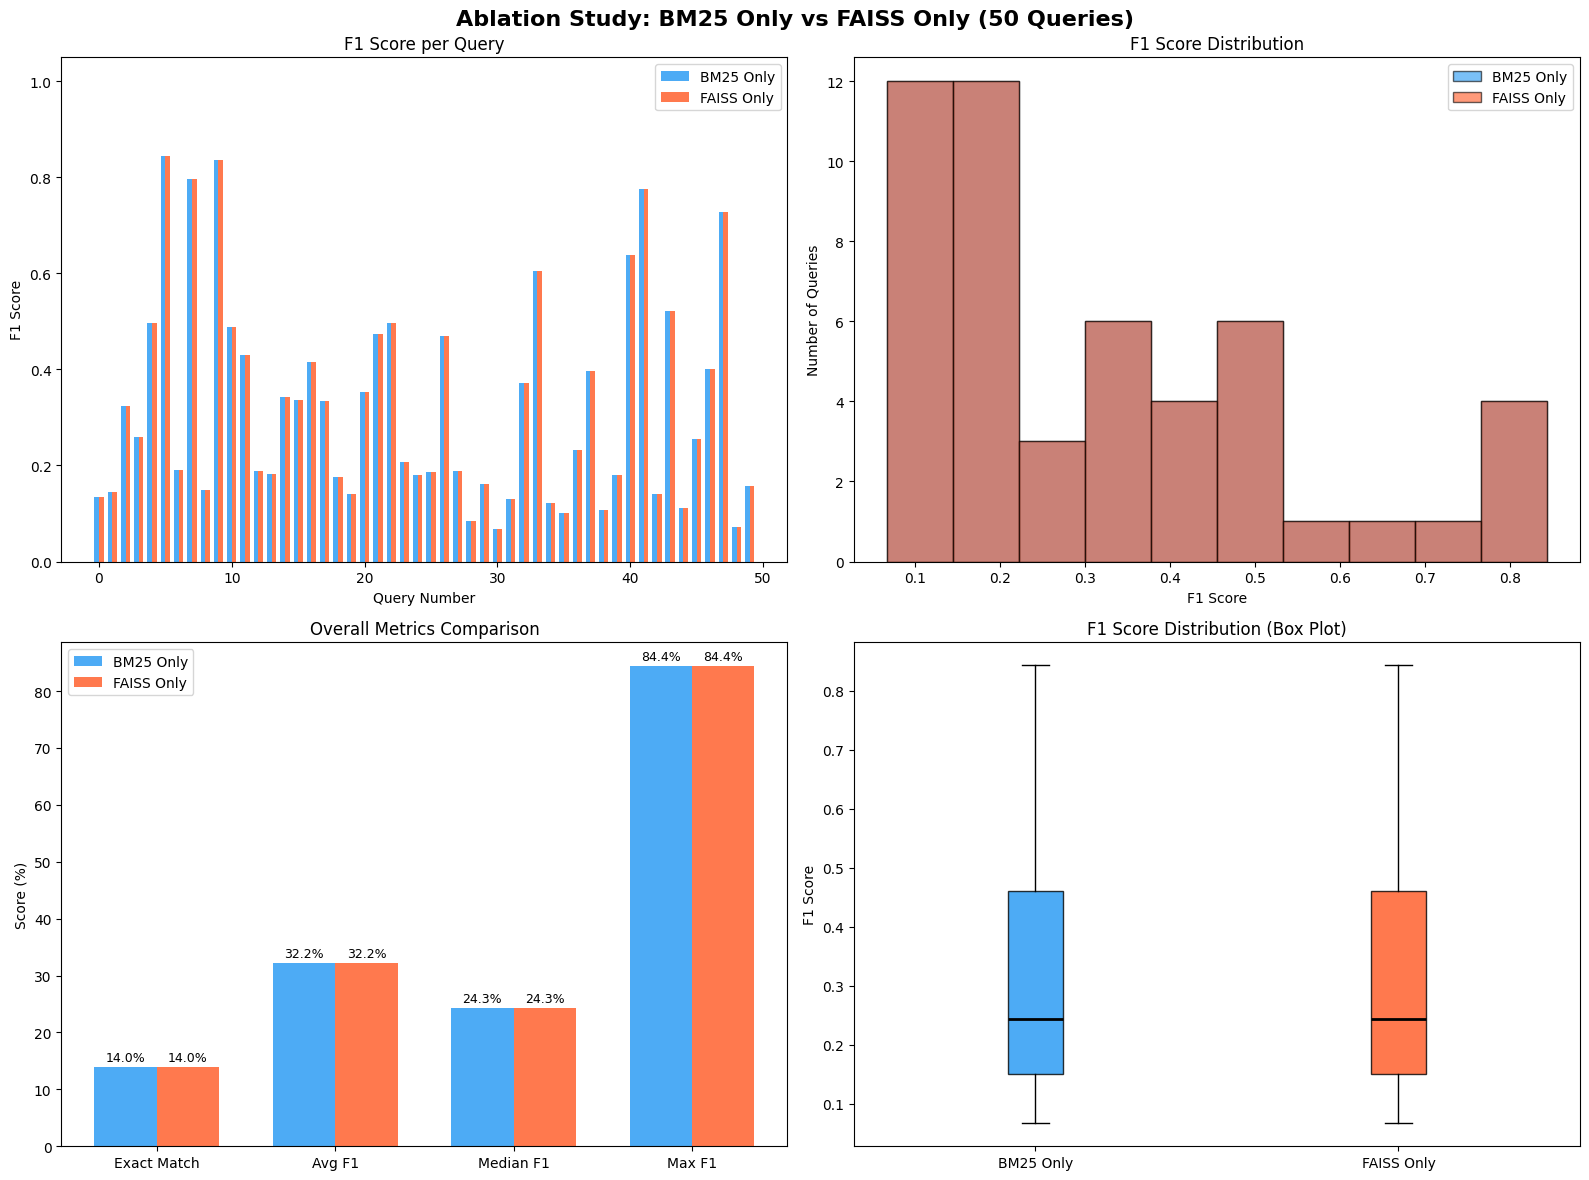

✅ Chart saved to Google Drive


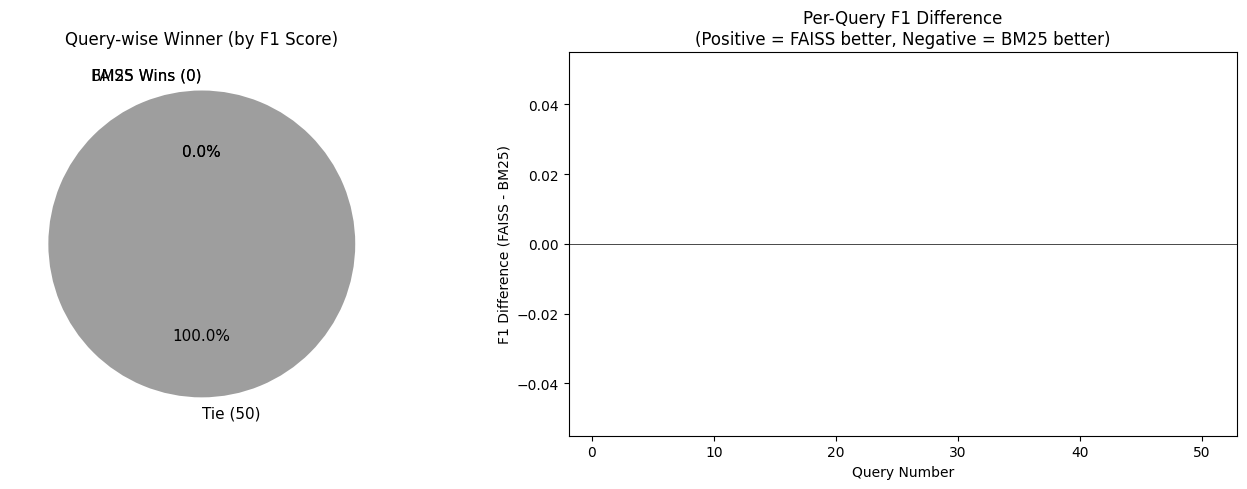

✅ Winner analysis chart saved to Google Drive

📊 FINAL COMPARISON SUMMARY

Metric                         BM25 Only          FAISS Only         Winner         
--------------------------------------------------------------------------------
Exact Match                    14.00              14.00              Tie            
F1 Score (Avg)                 32.24              32.24              Tie            
F1 Score (Median)              24.33              24.33              Tie            
F1 Score (Max)                 84.38              84.38              Tie            
Queries Won                    0.00               0.00               Tie            


In [ ]:
# ========================================================
# VISUALIZATION: BM25 Only vs FAISS Only Comparison
# ========================================================

!pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------
# Make sure both result lists exist:
# bm25_results_detailed (from BM25-only run)
# faiss_results_detailed (from FAISS-only run)
# --------------------------------------------------------

# Extract scores from both
bm25_f1 = [r['f1_score'] for r in bm25_results_detailed]
faiss_f1 = [r['f1_score'] for r in faiss_results_detailed]
bm25_em = [r['exact_match'] for r in bm25_results_detailed]
faiss_em = [r['exact_match'] for r in faiss_results_detailed]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ablation Study: BM25 Only vs FAISS Only (50 Queries)', fontsize=16, fontweight='bold')

# --------------------------------------------------------
# Plot 1: F1 Score Comparison (Bar Chart per Query)
# --------------------------------------------------------
ax1 = axes[0, 0]
x = np.arange(len(bm25_f1))
width = 0.35
ax1.bar(x - width/2, bm25_f1, width, label='BM25 Only', color='#2196F3', alpha=0.8)
ax1.bar(x + width/2, faiss_f1, width, label='FAISS Only', color='#FF5722', alpha=0.8)
ax1.set_xlabel('Query Number')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score per Query')
ax1.legend()
ax1.set_ylim(0, 1.05)

# --------------------------------------------------------
# Plot 2: F1 Score Distribution (Histogram)
# --------------------------------------------------------
ax2 = axes[0, 1]
ax2.hist(bm25_f1, bins=10, alpha=0.6, label='BM25 Only', color='#2196F3', edgecolor='black')
ax2.hist(faiss_f1, bins=10, alpha=0.6, label='FAISS Only', color='#FF5722', edgecolor='black')
ax2.set_xlabel('F1 Score')
ax2.set_ylabel('Number of Queries')
ax2.set_title('F1 Score Distribution')
ax2.legend()

# --------------------------------------------------------
# Plot 3: Overall Metrics Comparison (Grouped Bar)
# --------------------------------------------------------
ax3 = axes[1, 0]
metrics = ['Exact Match', 'Avg F1', 'Median F1', 'Max F1']
bm25_vals = [
    np.mean(bm25_em) * 100,
    np.mean(bm25_f1) * 100,
    np.median(bm25_f1) * 100,
    np.max(bm25_f1) * 100
]
faiss_vals = [
    np.mean(faiss_em) * 100,
    np.mean(faiss_f1) * 100,
    np.median(faiss_f1) * 100,
    np.max(faiss_f1) * 100
]

x_metrics = np.arange(len(metrics))
bars1 = ax3.bar(x_metrics - width/2, bm25_vals, width, label='BM25 Only', color='#2196F3', alpha=0.8)
bars2 = ax3.bar(x_metrics + width/2, faiss_vals, width, label='FAISS Only', color='#FF5722', alpha=0.8)
ax3.set_ylabel('Score (%)')
ax3.set_title('Overall Metrics Comparison')
ax3.set_xticks(x_metrics)
ax3.set_xticklabels(metrics)
ax3.legend()

# Add value labels on bars
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# --------------------------------------------------------
# Plot 4: F1 Score Box Plot
# --------------------------------------------------------
ax4 = axes[1, 1]
bp = ax4.boxplot(
    [bm25_f1, faiss_f1],
    labels=['BM25 Only', 'FAISS Only'],
    patch_artist=True,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
ax4.set_ylabel('F1 Score')
ax4.set_title('F1 Score Distribution (Box Plot)')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"bm25_vs_faiss_comparison_{timestamp}.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved to Google Drive")

# --------------------------------------------------------
# Plot 5: Query-wise Winner Analysis
# --------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Who wins per query
bm25_wins = sum(1 for b, f in zip(bm25_f1, faiss_f1) if b > f)
faiss_wins = sum(1 for b, f in zip(bm25_f1, faiss_f1) if f > b)
ties = sum(1 for b, f in zip(bm25_f1, faiss_f1) if b == f)

ax5 = axes2[0]
colors = ['#2196F3', '#FF5722', '#9E9E9E']
ax5.pie([bm25_wins, faiss_wins, ties],
        labels=[f'BM25 Wins ({bm25_wins})', f'FAISS Wins ({faiss_wins})', f'Tie ({ties})'],
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 11})
ax5.set_title('Query-wise Winner (by F1 Score)')

# F1 difference scatter
ax6 = axes2[1]
f1_diff = [f - b for b, f in zip(bm25_f1, faiss_f1)]
colors_scatter = ['#FF5722' if d > 0 else '#2196F3' if d < 0 else '#9E9E9E' for d in f1_diff]
ax6.bar(range(1, 51), f1_diff, color=colors_scatter, alpha=0.8)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax6.set_xlabel('Query Number')
ax6.set_ylabel('F1 Difference (FAISS - BM25)')
ax6.set_title('Per-Query F1 Difference\n(Positive = FAISS better, Negative = BM25 better)')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"bm25_vs_faiss_winner_{timestamp}.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Winner analysis chart saved to Google Drive")

# --------------------------------------------------------
# Print Summary Table
# --------------------------------------------------------
print("\n" + "="*80)
print("📊 FINAL COMPARISON SUMMARY")
print("="*80)
print(f"\n{'Metric':<30} {'BM25 Only':<18} {'FAISS Only':<18} {'Winner':<15}")
print("-"*80)

comparisons = [
    ('Exact Match', np.mean(bm25_em)*100, np.mean(faiss_em)*100),
    ('F1 Score (Avg)', np.mean(bm25_f1)*100, np.mean(faiss_f1)*100),
    ('F1 Score (Median)', np.median(bm25_f1)*100, np.median(faiss_f1)*100),
    ('F1 Score (Max)', np.max(bm25_f1)*100, np.max(faiss_f1)*100),
    ('Queries Won', bm25_wins, faiss_wins),
]

for metric, bm25_val, faiss_val in comparisons:
    if bm25_val > faiss_val:
        winner = "BM25 ✅"
    elif faiss_val > bm25_val:
        winner = "FAISS ✅"
    else:
        winner = "Tie"
    print(f"{metric:<30} {bm25_val:<18.2f} {faiss_val:<18.2f} {winner:<15}")

Checking retrieval overlap between BM25 and FAISS...

📊 RETRIEVAL OVERLAP ANALYSIS

Metric                                   Value          
-------------------------------------------------------
Same Top-1 Chunk                         50/50 (100.0%)
Avg Top-5 Overlap                        2.1/5

Queries with Different Top-1             0/50

⚠️  All 50 queries retrieved the EXACT same top chunk!
   This means the cross-encoder reranker dominates the final ranking.
   Both BM25 and FAISS feed similar candidates, and reranker picks the same winner.


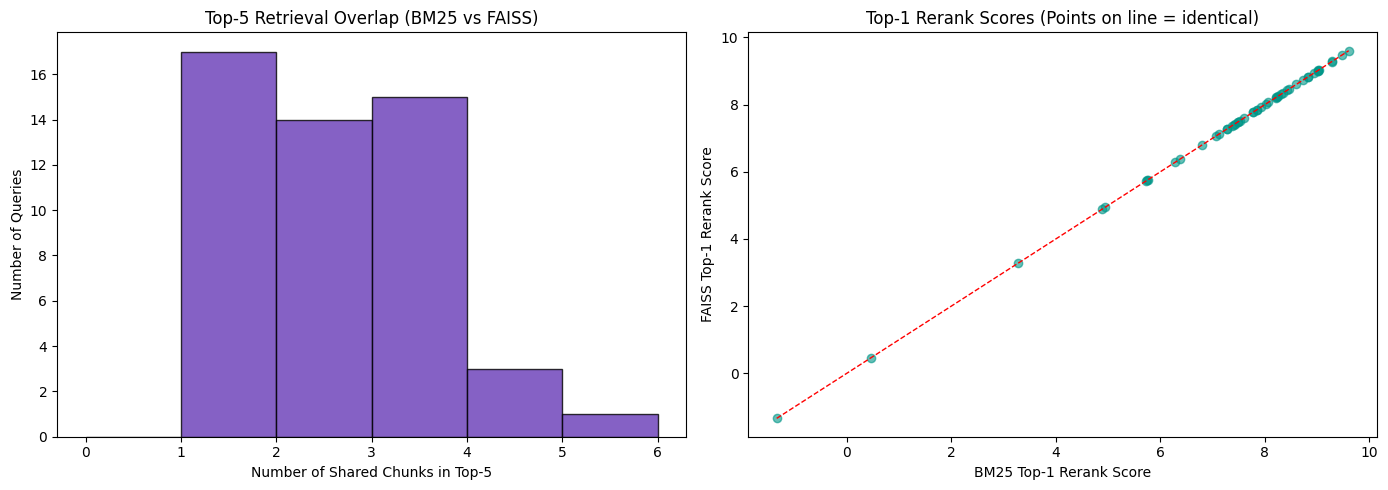


✅ Chart saved to Google Drive


In [ ]:
# ========================================================
# DIAGNOSIS: Why are BM25 and FAISS results identical?
# ========================================================

print("Checking retrieval overlap between BM25 and FAISS...\n")

same_top1 = 0
same_top5 = 0
retrieval_details = []

for idx, query in enumerate(test_queries[:50]):
    # Get BM25 results
    bm25_results = bm25_only_search(query, top_k=10)
    bm25_top1 = bm25_results[0]['chunk_idx']
    bm25_top5 = set([r['chunk_idx'] for r in bm25_results[:5]])

    # Get FAISS results
    faiss_results = faiss_only_search(query, top_k=10)
    faiss_top1 = faiss_results[0]['chunk_idx']
    faiss_top5 = set([r['chunk_idx'] for r in faiss_results[:5]])

    # Check overlap
    top1_match = bm25_top1 == faiss_top1
    top5_overlap = len(bm25_top5 & faiss_top5)

    if top1_match:
        same_top1 += 1
    same_top5 += top5_overlap

    retrieval_details.append({
        'query_number': idx + 1,
        'bm25_top1_chunk': bm25_top1,
        'faiss_top1_chunk': faiss_top1,
        'top1_same': top1_match,
        'top5_overlap': top5_overlap,
        'bm25_top1_rerank': bm25_results[0]['rerank_score'],
        'faiss_top1_rerank': faiss_results[0]['rerank_score']
    })

print("="*80)
print("📊 RETRIEVAL OVERLAP ANALYSIS")
print("="*80)
print(f"\n{'Metric':<40} {'Value':<15}")
print("-"*55)
print(f"{'Same Top-1 Chunk':<40} {same_top1}/50 ({same_top1/50*100:.1f}%)")
print(f"{'Avg Top-5 Overlap':<40} {same_top5/50:.1f}/5")

# Show queries where retrieval differs
diff_queries = [r for r in retrieval_details if not r['top1_same']]
print(f"\n{'Queries with Different Top-1':<40} {len(diff_queries)}/50")

if diff_queries:
    print(f"\n{'Query #':<12} {'BM25 Chunk':<15} {'FAISS Chunk':<15} {'BM25 Rerank':<15} {'FAISS Rerank':<15}")
    print("-"*72)
    for r in diff_queries[:10]:
        print(f"{r['query_number']:<12} {r['bm25_top1_chunk']:<15} {r['faiss_top1_chunk']:<15} {r['bm25_top1_rerank']:<15.4f} {r['faiss_top1_rerank']:<15.4f}")
else:
    print("\n⚠️  All 50 queries retrieved the EXACT same top chunk!")
    print("   This means the cross-encoder reranker dominates the final ranking.")
    print("   Both BM25 and FAISS feed similar candidates, and reranker picks the same winner.")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-5 overlap distribution
overlaps = [r['top5_overlap'] for r in retrieval_details]
axes[0].hist(overlaps, bins=range(0, 7), alpha=0.8, color='#673AB7', edgecolor='black')
axes[0].set_xlabel('Number of Shared Chunks in Top-5')
axes[0].set_ylabel('Number of Queries')
axes[0].set_title('Top-5 Retrieval Overlap (BM25 vs FAISS)')

# Rerank score comparison
bm25_rerank = [r['bm25_top1_rerank'] for r in retrieval_details]
faiss_rerank = [r['faiss_top1_rerank'] for r in retrieval_details]
axes[1].scatter(bm25_rerank, faiss_rerank, alpha=0.6, color='#009688')
min_val = min(min(bm25_rerank), min(faiss_rerank))
max_val = max(max(bm25_rerank), max(faiss_rerank))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[1].set_xlabel('BM25 Top-1 Rerank Score')
axes[1].set_ylabel('FAISS Top-1 Rerank Score')
axes[1].set_title('Top-1 Rerank Scores (Points on line = identical)')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"retrieval_overlap_analysis_{timestamp}.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Chart saved to Google Drive")

Running Raw BM25 vs Raw FAISS Evaluation (No Reranker)...

Evaluating query 50/50...

Retrieval overlap (no reranker): 50/50 same top-1 chunk

📊 RAW RETRIEVAL COMPARISON - NO RERANKER (50 Queries)

Metric                         Raw BM25           Raw FAISS          Winner         
--------------------------------------------------------------------------------
Exact Match                    14.00              14.00              Tie            
F1 Score (Avg)                 32.24              32.24              Tie            
F1 Score (Median)              24.33              24.33              Tie            
F1 Score (Max)                 84.38              84.38              Tie            


/tmp/ipykernel_137/626228164.py:196: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot([raw_bm25_f1, raw_faiss_f1], labels=['Raw BM25', 'Raw FAISS'], patch_artist=True, medianprops=dict(color='black', linewidth=2))


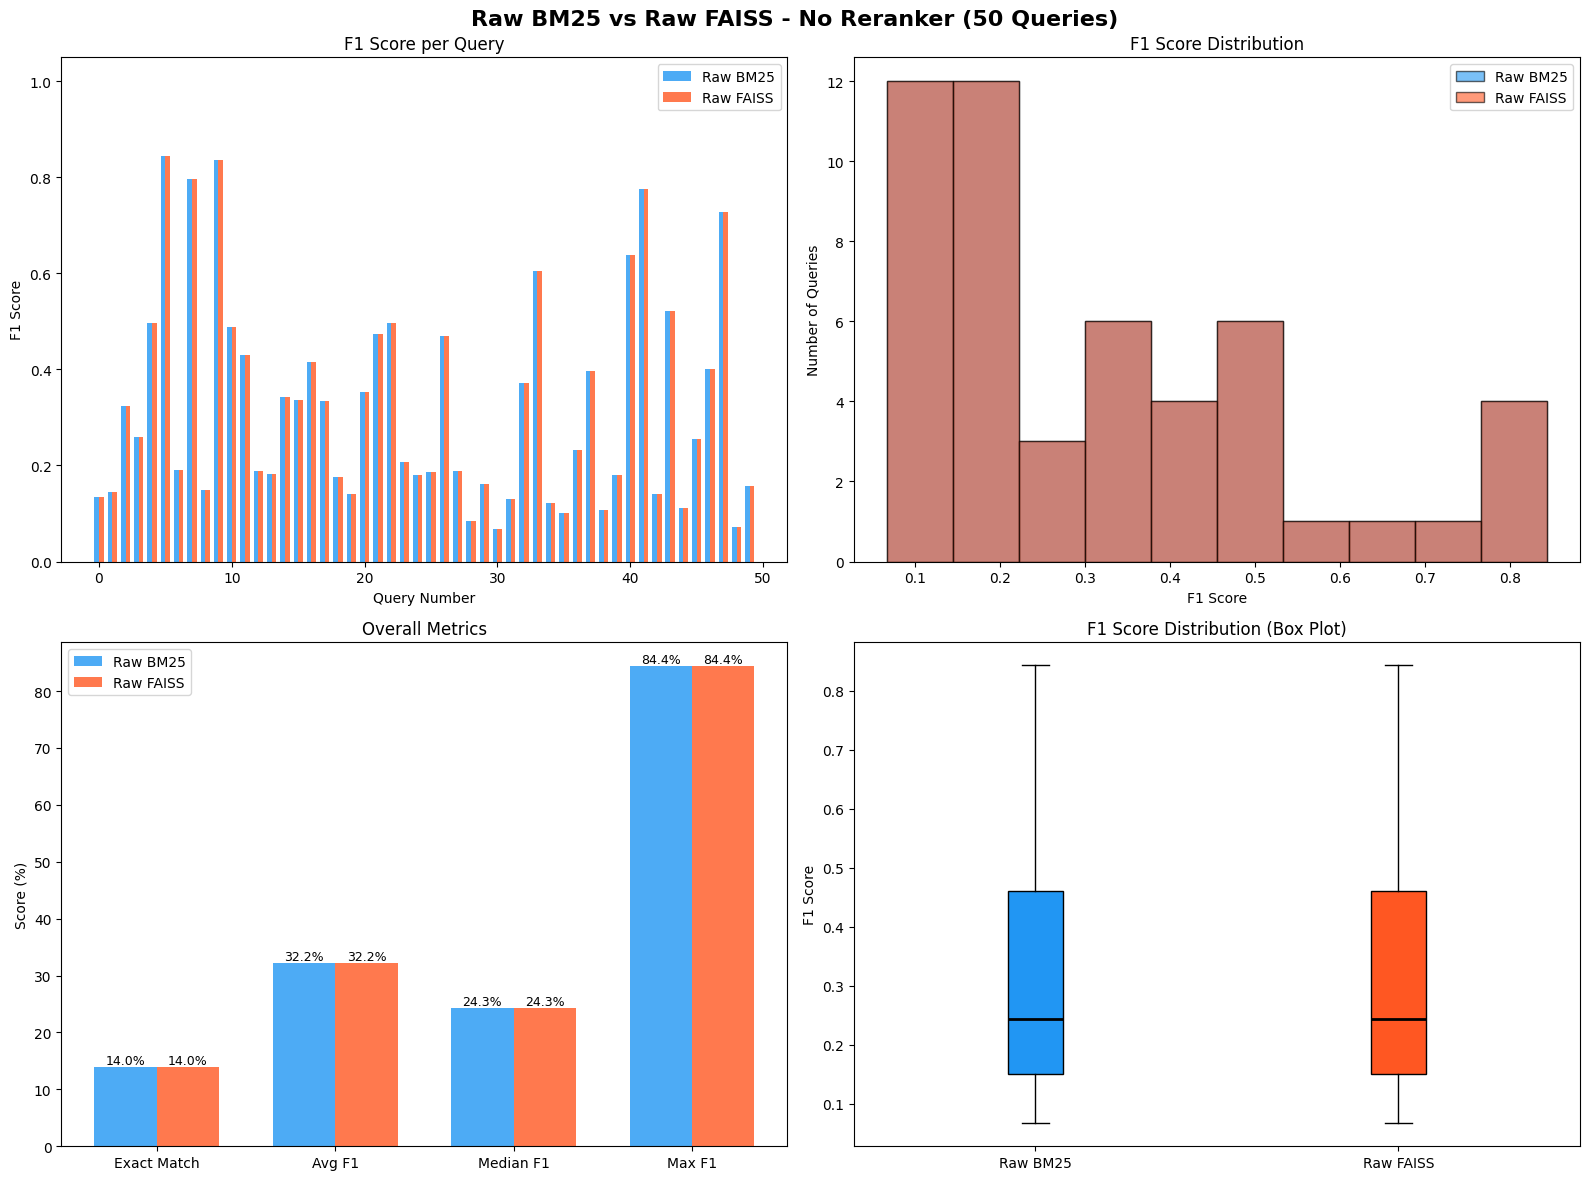

✅ Charts saved to Google Drive
✅ Raw BM25 results saved to: /content/drive/MyDrive/healthcare_rag_chunks/raw_bm25_results_20260304_151859.csv
✅ Raw FAISS results saved to: /content/drive/MyDrive/healthcare_rag_chunks/raw_faiss_results_20260304_151859.csv


In [ ]:
# ========================================================
# ABLATION: Raw BM25 vs Raw FAISS (No Reranker)
# ========================================================

def raw_bm25_search(query, top_k=10):
    """BM25 only, NO reranker"""
    tokenized_query = simple_tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'chunk_idx': int(idx),
            'score': float(scores[idx]),
            'chunk': all_chunks[int(idx)]
        })
    return results


def raw_faiss_search(query, top_k=10):
    """FAISS only, NO reranker"""
    query_embedding = embedding_model.encode(
        [query], convert_to_numpy=True, normalize_embeddings=True
    )
    scores, indices = faiss_index.search(query_embedding.astype('float32'), top_k)

    results = []
    for idx, score in zip(indices[0], scores[0]):
        results.append({
            'chunk_idx': int(idx),
            'score': float(score),
            'chunk': all_chunks[int(idx)]
        })
    return results


def rag_pipeline_raw(query, search_fn, top_k=10):
    """RAG pipeline with raw retrieval (no reranker)"""
    search_results = search_fn(query, top_k=top_k)

    if not search_results:
        return {
            'query': query,
            'answer': "I couldn't find relevant information.",
            'context': None,
            'top_chunks': []
        }

    top_chunk = search_results[0]['chunk']
    full_context = f"Doctor's Answer: {top_chunk['answer']}"
    answer = generate_answer(query, full_context, max_length=1024)

    return {
        'query': query,
        'answer': answer,
        'context': full_context,
        'top_chunks': [
            {
                'chunk_id': r['chunk']['chunk_id'],
                'question': r['chunk']['question'][:200],
                'answer': r['chunk']['answer'][:200],
                'score': r['score']
            }
            for r in search_results[:5]
        ]
    }


# ========================================================
# RUN EVALUATION: Raw BM25 vs Raw FAISS (50 Queries)
# ========================================================

print("Running Raw BM25 vs Raw FAISS Evaluation (No Reranker)...\n")

raw_bm25_em, raw_bm25_f1, raw_bm25_detailed = [], [], []
raw_faiss_em, raw_faiss_f1, raw_faiss_detailed = [], [], []

for idx, (query, truth) in enumerate(zip(test_queries[:50], ground_truths[:50]), 1):
    print(f"\rEvaluating query {idx}/50...", end="", flush=True)

    # Raw BM25
    result_bm25 = rag_pipeline_raw(query, raw_bm25_search, top_k=10)
    pred_bm25 = result_bm25['answer']
    em_b = exact_match_score(pred_bm25, truth)
    f1_b = f1_score_tokens(pred_bm25, truth)
    raw_bm25_em.append(em_b)
    raw_bm25_f1.append(f1_b)
    raw_bm25_detailed.append({
        'query_number': idx, 'question': query[:200],
        'ground_truth': truth[:300], 'prediction': pred_bm25[:300],
        'exact_match': em_b, 'f1_score': round(f1_b, 4)
    })

    # Raw FAISS
    result_faiss = rag_pipeline_raw(query, raw_faiss_search, top_k=10)
    pred_faiss = result_faiss['answer']
    em_f = exact_match_score(pred_faiss, truth)
    f1_f = f1_score_tokens(pred_faiss, truth)
    raw_faiss_em.append(em_f)
    raw_faiss_f1.append(f1_f)
    raw_faiss_detailed.append({
        'query_number': idx, 'question': query[:200],
        'ground_truth': truth[:300], 'prediction': pred_faiss[:300],
        'exact_match': em_f, 'f1_score': round(f1_f, 4)
    })

# ========================================================
# CHECK RETRIEVAL DIFFERENCE
# ========================================================

same_top1 = 0
for idx, query in enumerate(test_queries[:50]):
    bm25_res = raw_bm25_search(query, top_k=1)
    faiss_res = raw_faiss_search(query, top_k=1)
    if bm25_res[0]['chunk_idx'] == faiss_res[0]['chunk_idx']:
        same_top1 += 1

print(f"\n\nRetrieval overlap (no reranker): {same_top1}/50 same top-1 chunk")

# ========================================================
# PRINT COMPARISON
# ========================================================

print("\n" + "="*80)
print("📊 RAW RETRIEVAL COMPARISON - NO RERANKER (50 Queries)")
print("="*80)

print(f"\n{'Metric':<30} {'Raw BM25':<18} {'Raw FAISS':<18} {'Winner':<15}")
print("-"*80)

comparisons = [
    ('Exact Match', np.mean(raw_bm25_em)*100, np.mean(raw_faiss_em)*100),
    ('F1 Score (Avg)', np.mean(raw_bm25_f1)*100, np.mean(raw_faiss_f1)*100),
    ('F1 Score (Median)', np.median(raw_bm25_f1)*100, np.median(raw_faiss_f1)*100),
    ('F1 Score (Max)', np.max(raw_bm25_f1)*100, np.max(raw_faiss_f1)*100),
]

for metric, bm25_val, faiss_val in comparisons:
    if bm25_val > faiss_val:
        winner = "BM25 ✅"
    elif faiss_val > bm25_val:
        winner = "FAISS ✅"
    else:
        winner = "Tie"
    print(f"{metric:<30} {bm25_val:<18.2f} {faiss_val:<18.2f} {winner:<15}")

# ========================================================
# VISUALIZATION
# ========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Raw BM25 vs Raw FAISS - No Reranker (50 Queries)', fontsize=16, fontweight='bold')

# Plot 1: F1 per query
ax1 = axes[0, 0]
x = np.arange(50)
width = 0.35
ax1.bar(x - width/2, raw_bm25_f1, width, label='Raw BM25', color='#2196F3', alpha=0.8)
ax1.bar(x + width/2, raw_faiss_f1, width, label='Raw FAISS', color='#FF5722', alpha=0.8)
ax1.set_xlabel('Query Number')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score per Query')
ax1.legend()
ax1.set_ylim(0, 1.05)

# Plot 2: F1 Distribution
ax2 = axes[0, 1]
ax2.hist(raw_bm25_f1, bins=10, alpha=0.6, label='Raw BM25', color='#2196F3', edgecolor='black')
ax2.hist(raw_faiss_f1, bins=10, alpha=0.6, label='Raw FAISS', color='#FF5722', edgecolor='black')
ax2.set_xlabel('F1 Score')
ax2.set_ylabel('Number of Queries')
ax2.set_title('F1 Score Distribution')
ax2.legend()

# Plot 3: Overall Metrics
ax3 = axes[1, 0]
metrics = ['Exact Match', 'Avg F1', 'Median F1', 'Max F1']
bm25_vals = [np.mean(raw_bm25_em)*100, np.mean(raw_bm25_f1)*100, np.median(raw_bm25_f1)*100, np.max(raw_bm25_f1)*100]
faiss_vals = [np.mean(raw_faiss_em)*100, np.mean(raw_faiss_f1)*100, np.median(raw_faiss_f1)*100, np.max(raw_faiss_f1)*100]
x_m = np.arange(len(metrics))
bars1 = ax3.bar(x_m - width/2, bm25_vals, width, label='Raw BM25', color='#2196F3', alpha=0.8)
bars2 = ax3.bar(x_m + width/2, faiss_vals, width, label='Raw FAISS', color='#FF5722', alpha=0.8)
ax3.set_ylabel('Score (%)')
ax3.set_title('Overall Metrics')
ax3.set_xticks(x_m)
ax3.set_xticklabels(metrics)
ax3.legend()
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)

# Plot 4: Box Plot
ax4 = axes[1, 1]
bp = ax4.boxplot([raw_bm25_f1, raw_faiss_f1], labels=['Raw BM25', 'Raw FAISS'], patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
ax4.set_ylabel('F1 Score')
ax4.set_title('F1 Score Distribution (Box Plot)')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"raw_bm25_vs_faiss_{timestamp}.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Charts saved to Google Drive")

# ========================================================
# SAVE RESULTS TO GOOGLE DRIVE
# ========================================================

# Save BM25 raw results
csv1 = os.path.join(save_dir, f"raw_bm25_results_{timestamp}.csv")
pd.DataFrame(raw_bm25_detailed).to_csv(csv1, index=False)

# Save FAISS raw results
csv2 = os.path.join(save_dir, f"raw_faiss_results_{timestamp}.csv")
pd.DataFrame(raw_faiss_detailed).to_csv(csv2, index=False)

print(f"✅ Raw BM25 results saved to: {csv1}")
print(f"✅ Raw FAISS results saved to: {csv2}")

In [ ]:
# ========================================================
# VERIFY: Are test queries finding their own source chunk?
# ========================================================

print("Checking if queries match their own source conversations...\n")

self_match = 0
for idx, query in enumerate(test_queries[:50]):
    results = raw_bm25_search(query, top_k=1)
    retrieved_chunk = results[0]['chunk']
    # Check if retrieved chunk's question matches the query
    if normalize_text(retrieved_chunk['question']) == normalize_text(query):
        self_match += 1

print(f"Self-matches: {self_match}/50 ({self_match/50*100:.1f}%)")
print("This confirms queries are finding their exact source conversation.\n")

Checking if queries match their own source conversations...

Self-matches: 50/50 (100.0%)
This confirms queries are finding their exact source conversation.



In [ ]:
# ========================================================
# MEANINGFUL ABLATION: Paraphrased Queries
# BM25 struggles with paraphrases, FAISS handles them better
# ========================================================

# Paraphrase test queries using FLAN-T5
def paraphrase_query(query):
    """Use FLAN-T5 to paraphrase the query"""
    prompt = f"Paraphrase this medical question using different words:\n{query[:300]}\n\nParaphrased question:"
    inputs = tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True).to(device)
    with torch.no_grad():
        outputs = generator_model.generate(
            **inputs, max_length=256, num_beams=4,
            no_repeat_ngram_size=3, temperature=0.8
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Generating paraphrased queries...\n")

paraphrased_queries = []
for idx, query in enumerate(test_queries[:50], 1):
    print(f"\rParaphrasing query {idx}/50...", end="", flush=True)
    paraphrased = paraphrase_query(query)
    paraphrased_queries.append(paraphrased)

# Show some examples
print("\n\nSample paraphrases:")
print("-"*80)
for i in range(3):
    print(f"\nOriginal:     {test_queries[i][:150]}...")
    print(f"Paraphrased:  {paraphrased_queries[i][:150]}...")

Generating paraphrased queries...

Paraphrasing query 1/50...

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Paraphrasing query 50/50...

Sample paraphrases:
--------------------------------------------------------------------------------

Original:     I woke up this morning feeling the whole room is spinning when i was sitting down. I went to the bathroom walking unsteadily, as i tried to focus i fe...
Paraphrased:  How do I know if I'm nauseous?...

Original:     My baby has been pooing 5-6 times a day for a week. In the last few days it has increased to 7 and they are very watery with green stringy bits in the...
Paraphrased:  My baby has been pooping 5-6 times a day for a week. In the last few days it has increased to 7 and they are very watery with green stringy bits in th...

Original:     Hello, My husband is taking Oxycodone due to a broken leg/surgery. He has been taking this pain medication for one month. We are trying to conceive ou...
Paraphrased:  Hello, My husband is taking Oxycodone due to a broken leg/surgery. He has been taking this pain medication for one month. We are tryi

In [ ]:
# ========================================================
# RUN ABLATION ON PARAPHRASED QUERIES
# ========================================================

print("Running Raw BM25 vs Raw FAISS on PARAPHRASED queries...\n")

para_bm25_em, para_bm25_f1, para_bm25_detailed = [], [], []
para_faiss_em, para_faiss_f1, para_faiss_detailed = [], [], []

same_top1_para = 0

for idx, (para_query, truth) in enumerate(zip(paraphrased_queries[:50], ground_truths[:50]), 1):
    print(f"\rEvaluating query {idx}/50...", end="", flush=True)

    # Check retrieval overlap
    bm25_res = raw_bm25_search(para_query, top_k=1)
    faiss_res = raw_faiss_search(para_query, top_k=1)
    if bm25_res[0]['chunk_idx'] == faiss_res[0]['chunk_idx']:
        same_top1_para += 1

    # Raw BM25
    result_bm25 = rag_pipeline_raw(para_query, raw_bm25_search, top_k=10)
    pred_bm25 = result_bm25['answer']
    em_b = exact_match_score(pred_bm25, truth)
    f1_b = f1_score_tokens(pred_bm25, truth)
    para_bm25_em.append(em_b)
    para_bm25_f1.append(f1_b)
    para_bm25_detailed.append({
        'query_number': idx, 'original_query': test_queries[idx-1][:200],
        'paraphrased_query': para_query[:200], 'ground_truth': truth[:300],
        'prediction': pred_bm25[:300], 'exact_match': em_b, 'f1_score': round(f1_b, 4)
    })

    # Raw FAISS
    result_faiss = rag_pipeline_raw(para_query, raw_faiss_search, top_k=10)
    pred_faiss = result_faiss['answer']
    em_f = exact_match_score(pred_faiss, truth)
    f1_f = f1_score_tokens(pred_faiss, truth)
    para_faiss_em.append(em_f)
    para_faiss_f1.append(f1_f)
    para_faiss_detailed.append({
        'query_number': idx, 'original_query': test_queries[idx-1][:200],
        'paraphrased_query': para_query[:200], 'ground_truth': truth[:300],
        'prediction': pred_faiss[:300], 'exact_match': em_f, 'f1_score': round(f1_f, 4)
    })

# ========================================================
# PRINT RESULTS
# ========================================================

print(f"\n\nRetrieval overlap (paraphrased): {same_top1_para}/50 same top-1 chunk")

bm25_wins = sum(1 for b, f in zip(para_bm25_f1, para_faiss_f1) if b > f)
faiss_wins = sum(1 for b, f in zip(para_bm25_f1, para_faiss_f1) if f > b)
ties = sum(1 for b, f in zip(para_bm25_f1, para_faiss_f1) if b == f)

print("\n" + "="*80)
print("📊 PARAPHRASED QUERIES: Raw BM25 vs Raw FAISS (50 Queries)")
print("="*80)

print(f"\n{'Metric':<30} {'Raw BM25':<18} {'Raw FAISS':<18} {'Winner':<15}")
print("-"*80)

comparisons = [
    ('Exact Match', np.mean(para_bm25_em)*100, np.mean(para_faiss_em)*100),
    ('F1 Score (Avg)', np.mean(para_bm25_f1)*100, np.mean(para_faiss_f1)*100),
    ('F1 Score (Median)', np.median(para_bm25_f1)*100, np.median(para_faiss_f1)*100),
    ('F1 Score (Max)', np.max(para_bm25_f1)*100, np.max(para_faiss_f1)*100),
    ('Queries Won', bm25_wins, faiss_wins),
]

for metric, bm25_val, faiss_val in comparisons:
    if bm25_val > faiss_val:
        winner = "BM25 ✅"
    elif faiss_val > bm25_val:
        winner = "FAISS ✅"
    else:
        winner = "Tie"
    print(f"{metric:<30} {bm25_val:<18.2f} {faiss_val:<18.2f} {winner:<15}")

Running Raw BM25 vs Raw FAISS on PARAPHRASED queries...

Evaluating query 50/50...

Retrieval overlap (paraphrased): 35/50 same top-1 chunk

📊 PARAPHRASED QUERIES: Raw BM25 vs Raw FAISS (50 Queries)

Metric                         Raw BM25           Raw FAISS          Winner         
--------------------------------------------------------------------------------
Exact Match                    8.00               8.00               Tie            
F1 Score (Avg)                 30.06              28.73              BM25 ✅         
F1 Score (Median)              23.54              19.83              BM25 ✅         
F1 Score (Max)                 77.55              77.55              Tie            
Queries Won                    9.00               6.00               BM25 ✅         


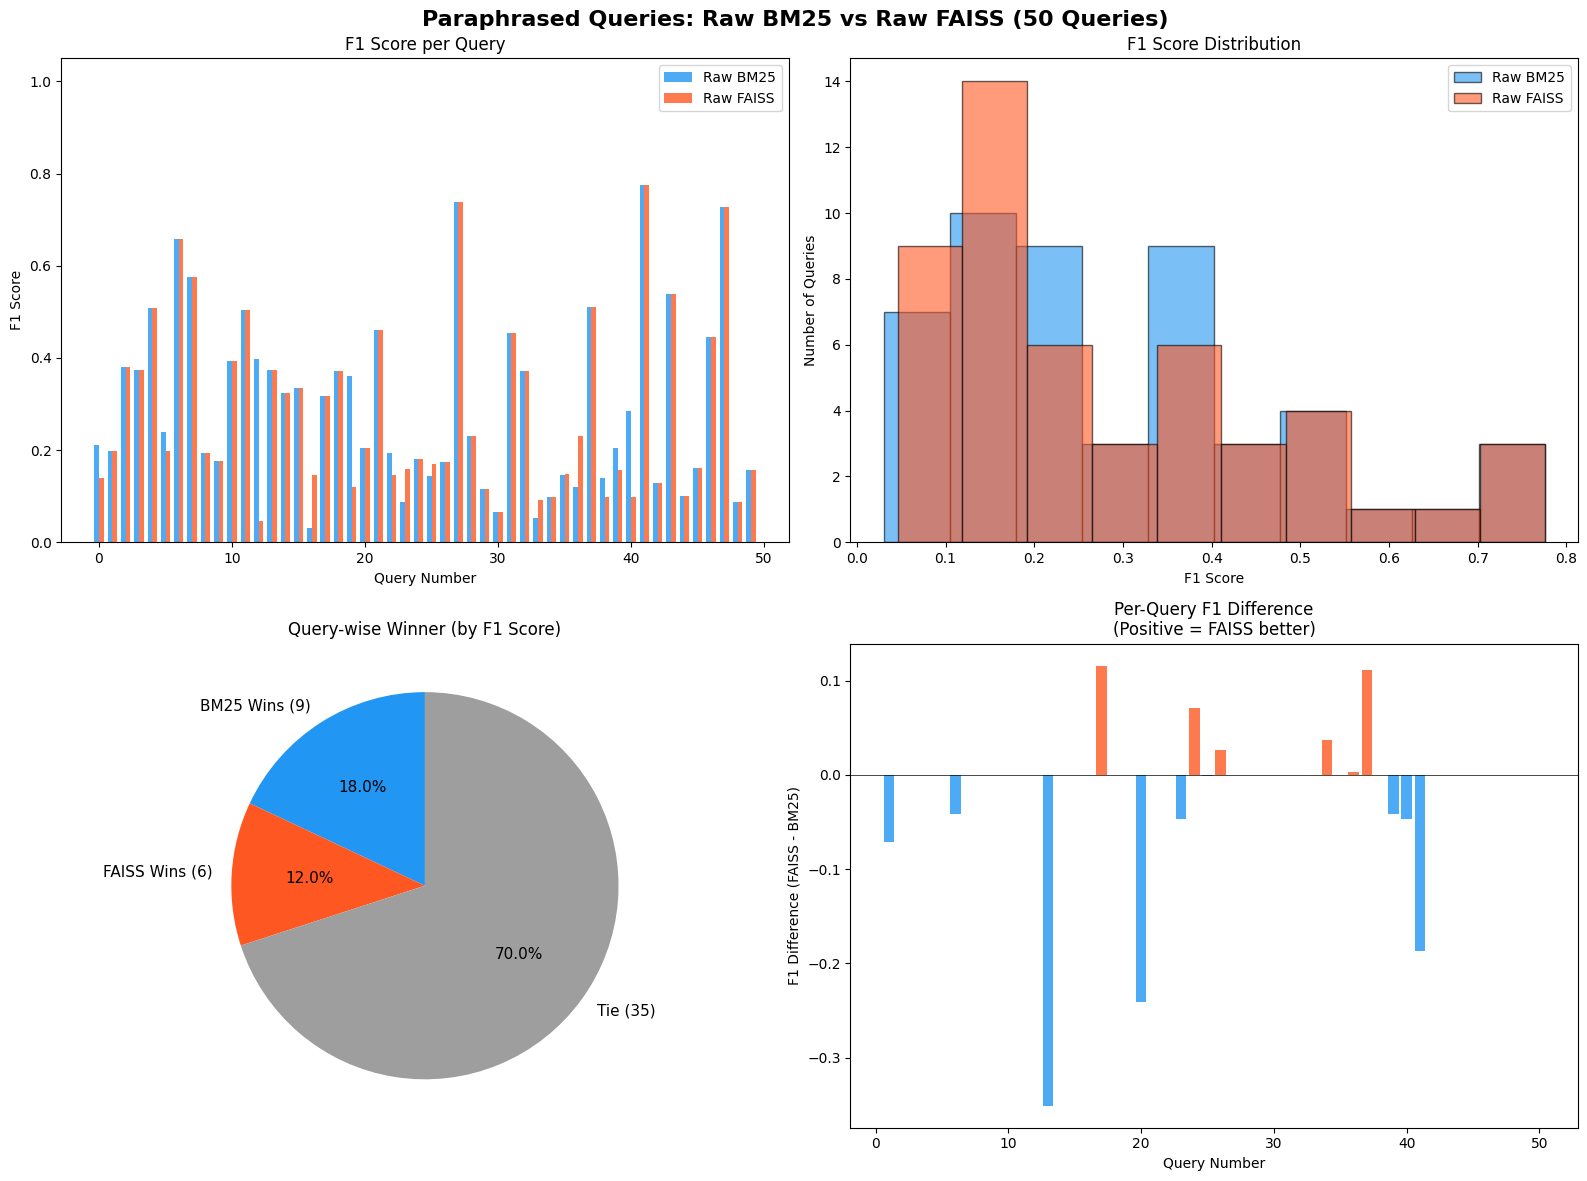

✅ All results saved to Google Drive


In [ ]:
# ========================================================
# VISUALIZATION: Paraphrased Query Results
# ========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Paraphrased Queries: Raw BM25 vs Raw FAISS (50 Queries)', fontsize=16, fontweight='bold')

# Plot 1: F1 per query
x = np.arange(50)
width = 0.35
axes[0,0].bar(x - width/2, para_bm25_f1, width, label='Raw BM25', color='#2196F3', alpha=0.8)
axes[0,0].bar(x + width/2, para_faiss_f1, width, label='Raw FAISS', color='#FF5722', alpha=0.8)
axes[0,0].set_xlabel('Query Number')
axes[0,0].set_ylabel('F1 Score')
axes[0,0].set_title('F1 Score per Query')
axes[0,0].legend()
axes[0,0].set_ylim(0, 1.05)

# Plot 2: F1 Distribution
axes[0,1].hist(para_bm25_f1, bins=10, alpha=0.6, label='Raw BM25', color='#2196F3', edgecolor='black')
axes[0,1].hist(para_faiss_f1, bins=10, alpha=0.6, label='Raw FAISS', color='#FF5722', edgecolor='black')
axes[0,1].set_xlabel('F1 Score')
axes[0,1].set_ylabel('Number of Queries')
axes[0,1].set_title('F1 Score Distribution')
axes[0,1].legend()

# Plot 3: Winner Pie Chart
axes[1,0].pie([bm25_wins, faiss_wins, ties],
    labels=[f'BM25 Wins ({bm25_wins})', f'FAISS Wins ({faiss_wins})', f'Tie ({ties})'],
    colors=['#2196F3', '#FF5722', '#9E9E9E'], autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11})
axes[1,0].set_title('Query-wise Winner (by F1 Score)')

# Plot 4: F1 Difference
f1_diff = [f - b for b, f in zip(para_bm25_f1, para_faiss_f1)]
colors_scatter = ['#FF5722' if d > 0 else '#2196F3' if d < 0 else '#9E9E9E' for d in f1_diff]
axes[1,1].bar(range(1, 51), f1_diff, color=colors_scatter, alpha=0.8)
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1,1].set_xlabel('Query Number')
axes[1,1].set_ylabel('F1 Difference (FAISS - BM25)')
axes[1,1].set_title('Per-Query F1 Difference\n(Positive = FAISS better)')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"paraphrased_bm25_vs_faiss_{timestamp}.png"), dpi=300, bbox_inches='tight')
plt.show()

# Save results
csv1 = os.path.join(save_dir, f"para_bm25_results_{timestamp}.csv")
csv2 = os.path.join(save_dir, f"para_faiss_results_{timestamp}.csv")
pd.DataFrame(para_bm25_detailed).to_csv(csv1, index=False)
pd.DataFrame(para_faiss_detailed).to_csv(csv2, index=False)
print(f"✅ All results saved to Google Drive")

### Explanation quality with gpt-4o

In [ ]:
# ========================================================
# CELL 1: Install OpenAI
# ========================================================
!pip install openai

In [ ]:
# ========================================================
# CELL 2: Setup OpenAI Client
# ========================================================
import openai

# Enter your OpenAI API key
OPENAI_API_KEY = "your-api-key-here"  # <-- Replace with your key
client = openai.OpenAI(api_key=OPENAI_API_KEY)
print("✅ OpenAI client ready")

✅ OpenAI client ready


In [ ]:
# ========================================================
# CELL 3: GPT-4o Explanation Quality Evaluator
# ========================================================

def evaluate_explanation_quality_gpt4o(query, answer, context):
    """
    Use GPT-4o to evaluate explanation quality across 4 dimensions.
    Returns scores (1-5) for each dimension and overall score.
    """
    prompt = f"""You are a medical expert evaluating the quality of a healthcare AI's response.

Patient Question:
{query[:500]}

Retrieved Medical Context:
{context[:1000]}

AI Generated Answer:
{answer[:1000]}

Evaluate the AI's answer on these 4 dimensions. Score each from 1 (worst) to 5 (best):

1. Relevance: Does the answer directly address the patient's question?
2. Completeness: Does it cover the key medical points from the context?
3. Clarity: Is it clear, well-structured, and easy for a patient to understand?
4. Medical Accuracy: Is it medically consistent with the provided context?

Respond ONLY in this exact JSON format, no other text:
{{"relevance": <score>, "completeness": <score>, "clarity": <score>, "medical_accuracy": <score>, "justification": "<brief 1-2 sentence explanation>"}}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
            max_tokens=200
        )

        response_text = response.choices[0].message.content.strip()
        # Clean markdown fences if present
        response_text = response_text.replace("```json", "").replace("```", "").strip()
        scores = json.loads(response_text)

        # Calculate overall score (average of 4 dimensions, normalized to 0-1)
        scores['overall'] = round(
            (scores['relevance'] + scores['completeness'] + scores['clarity'] + scores['medical_accuracy']) / 20, 4
        )
        return scores

    except Exception as e:
        print(f"\n⚠️ GPT-4o error: {e}")
        return {
            'relevance': 0, 'completeness': 0, 'clarity': 0,
            'medical_accuracy': 0, 'overall': 0, 'justification': f"Error: {e}"
        }

In [ ]:
# ========================================================
# CELL 4: Run GPT-4o Evaluation on 50 Queries
# ========================================================
import time

print("Running GPT-4o Explanation Quality Evaluation on 50 queries...\n")

relevance_scores = []
completeness_scores = []
clarity_scores = []
accuracy_scores = []
overall_scores = []

for idx, r in enumerate(faiss_results_detailed, 1):
    print(f"\rEvaluating query {idx}/50...", end="", flush=True)

    context = r['context_used'] if r['context_used'] else ""
    prediction = r['prediction']
    question = r['question']

    scores = evaluate_explanation_quality_gpt4o(question, prediction, context)

    relevance_scores.append(scores['relevance'])
    completeness_scores.append(scores['completeness'])
    clarity_scores.append(scores['clarity'])
    accuracy_scores.append(scores['medical_accuracy'])
    overall_scores.append(scores['overall'])

    # Update results
    r['gpt4o_relevance'] = scores['relevance']
    r['gpt4o_completeness'] = scores['completeness']
    r['gpt4o_clarity'] = scores['clarity']
    r['gpt4o_medical_accuracy'] = scores['medical_accuracy']
    r['gpt4o_overall'] = scores['overall']
    r['gpt4o_justification'] = scores.get('justification', '')

    # Small delay to avoid rate limits
    time.sleep(0.5)

In [ ]:
# ========================================================
# CELL 5: Print Evaluation Results
# ========================================================

print("\n\n" + "="*80)
print("📊 GPT-4o EXPLANATION QUALITY EVALUATION (50 Queries)")
print("="*80)

print(f"\n{'Dimension':<30} {'Avg (1-5)':<15} {'Min':<10} {'Max':<10}")
print("-"*65)
print(f"{'Relevance':<30} {np.mean(relevance_scores):.2f}{'':<9} {min(relevance_scores)}{'':<6} {max(relevance_scores)}")
print(f"{'Completeness':<30} {np.mean(completeness_scores):.2f}{'':<9} {min(completeness_scores)}{'':<6} {max(completeness_scores)}")
print(f"{'Clarity':<30} {np.mean(clarity_scores):.2f}{'':<9} {min(clarity_scores)}{'':<6} {max(clarity_scores)}")
print(f"{'Medical Accuracy':<30} {np.mean(accuracy_scores):.2f}{'':<9} {min(accuracy_scores)}{'':<6} {max(accuracy_scores)}")
print("-"*65)
print(f"{'Overall Quality (0-1)':<30} {np.mean(overall_scores):.4f}")

# Distribution
excellent = sum(1 for s in overall_scores if s >= 0.8)
good = sum(1 for s in overall_scores if 0.6 <= s < 0.8)
average = sum(1 for s in overall_scores if 0.4 <= s < 0.6)
poor = sum(1 for s in overall_scores if s < 0.4)

print(f"\n{'Quality Distribution':<30}")
print("-"*50)
print(f"{'  Excellent (≥ 0.8)':<30} {excellent}/50 ({excellent/50*100:.1f}%)")
print(f"{'  Good (0.6 - 0.8)':<30} {good}/50 ({good/50*100:.1f}%)")
print(f"{'  Average (0.4 - 0.6)':<30} {average}/50 ({average/50*100:.1f}%)")
print(f"{'  Poor (< 0.4)':<30} {poor}/50 ({poor/50*100:.1f}%)")

In [ ]:
# ========================================================
# CELL 6: Save Results to Google Drive
# ========================================================

save_dir = '/content/drive/MyDrive/healthcare_rag_chunks'
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, f"faiss_only_gpt4o_quality_{timestamp}.csv")
eval_df = pd.DataFrame(faiss_results_detailed)
eval_df.to_csv(csv_path, index=False)
print(f"✅ Results saved to Google Drive: {csv_path}")